In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Load the merged dataset
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape: (36673, 35)

Columns: ['Customer_ID', 'Product_ID', 'Category', 'event_type', 'Interaction_Value', 'Timestamp', 'Time_Spent_Seconds', 'hour', 'day_of_week', 'month', 'Subcategory', 'Price', 'Brand', 'Average_Rating_of_Similar_Products', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'Holiday_x', 'Season_x', 'Geographical_Location', 'Probability_of_Recommendation', 'similar_product_count', 'Age', 'Gender', 'Location', 'Customer_Segment', 'Avg_Order_Value', 'Holiday_y', 'Season_y', 'income', 'browse_count', 'purchase_count', 'already_purchased', 'interaction_score', 'price_segment', 'engagement_level']

First 3 rows:


,Customer_ID,Product_ID,Category,event_type,Interaction_Value,Timestamp,Time_Spent_Seconds,hour,day_of_week,month,...,Avg_Order_Value,Holiday_y,Season_y,income,browse_count,purchase_count,already_purchased,interaction_score,price_segment,engagement_level
0,C10294,P8646,Beauty,view,1.47,2025-10-19 13:47:08.004929,97,13,6,10,...,3826.59,No,Spring,102082,2,2,False,1,premium,medium
1,C10294,P4866,Home Decor,view,3.35,2025-05-31 07:45:44.012479,78,7,5,5,...,3826.59,No,Spring,102082,2,2,False,1,premium,medium
2,C10294,P8939,Home Decor,view,1.85,2025-09-22 08:24:19.020474,26,8,0,9,...,3826.59,No,Spring,102082,2,2,False,1,premium,low


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
# Step 1 — Import all required libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


In [5]:
# Step 2 — Prepare Data for DeepFM
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Categorical features
categorical_cols = [
    'Customer_ID', 'Product_ID', 'Category', 'Subcategory',
    'event_type', 'Gender', 'Location',
    'Customer_Segment', 'price_segment', 'engagement_level',
    'Season_x'
]

# Numerical features
numerical_cols = [
    'Age', 'Price', 'income', 'Interaction_Value',
    'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
    'Product_Rating', 'browse_count', 'purchase_count',
    'interaction_score', 'already_purchased'
]

# Target column
target_col = 'Probability_of_Recommendation'

# Encode categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded!")

# Scale numerical columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical columns scaled!")

# Prepare X and y
feature_cols = categorical_cols + numerical_cols
X = df[feature_cols].values
y = df[target_col].values

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Categorical columns encoded!
Numerical columns scaled!

Training samples : 29338
Testing samples  : 7335
Number of features: 24


In [6]:
# Step 3 — Build Baseline Neural Network Model
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Build simple neural network
def build_baseline_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

baseline_model = build_baseline_model(X_train.shape[1])
baseline_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Step 4 — Train Baseline Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training baseline model...")

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

print("\nBaseline model training complete!")

Training baseline model...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.2809 - mae: 0.4603 - val_loss: 0.2673 - val_mae: 0.4469
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2695 - mae: 0.4493 - val_loss: 0.2673 - val_mae: 0.4469
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2693 - mae: 0.4493 - val_loss: 0.2673 - val_mae: 0.4469
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2669 - mae: 0.4462 - val_loss: 0.2673 - val_mae: 0.4469

Baseline model training complete!


In [8]:
# Step 5 — Build DeepFM Model
from tensorflow.keras.layers import Embedding, Flatten, Concatenate, Multiply, Lambda
import tensorflow.keras.backend as K

def build_deepfm_model(num_features, embedding_dim=8):
    # Input layer
    inputs = Input(shape=(num_features,))

    # ── FM Part ──────────────────────────────
    # First order (linear) terms
    first_order = Dense(1, use_bias=True)(inputs)

    # Second order (interaction) terms
    # Reshape input for FM interaction
    square_of_sum = Lambda(lambda x: K.square(
        K.sum(tf.reshape(x, (-1, num_features, 1)), axis=1)))(inputs)

    sum_of_square = Lambda(lambda x: K.sum(
        K.square(tf.reshape(x, (-1, num_features, 1))), axis=1))(inputs)

    fm_second_order = Lambda(
        lambda x: 0.5 * K.sum(x[0] - x[1], axis=1, keepdims=True)
    )([square_of_sum, sum_of_square])

    # ── Deep Part ────────────────────────────
    deep = Dense(400, activation='relu')(inputs)
    deep = Dropout(0.3)(deep)
    deep = Dense(400, activation='relu')(deep)
    deep = Dropout(0.3)(deep)
    deep = Dense(400, activation='relu')(deep)
    deep = Dropout(0.3)(deep)

    # ── Combine FM + Deep ────────────────────
    combined = Concatenate()([first_order, fm_second_order, deep])
    output = Dense(1, activation='sigmoid')(combined)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

deepfm_model = build_deepfm_model(X_train.shape[1])
deepfm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 400)       │     10,000 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 400)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 400)       │    160,400 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 400)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 400)       │    160,400 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         25 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ lambda[0][0],     │
│                     │                   │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 400)       │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 402)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ lambda_2[0][0],   │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        403 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 331,228 (1.26 MB)

 Trainable params: 331,228 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Step 6 — Train DeepFM Model
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("Training DeepFM model...")

deepfm_history = deepfm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

print("\nDeepFM model training complete!")

Training DeepFM model...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 0.2671 - mae: 0.4462 - val_loss: 0.2673 - val_mae: 0.4469
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2666 - mae: 0.4455 - val_loss: 0.2673 - val_mae: 0.4469
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2667 - mae: 0.4469 - val_loss: 0.2673 - val_mae: 0.4469
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2671 - mae: 0.4464 - val_loss: 0.2673 - val_mae: 0.4469

DeepFM model training complete!


230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
230/230 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Metric            Baseline     DeepFM
MSE                 0.2673     0.2673
MAE                 0.4469     0.4469
R2 Score           -2.9569    -2.9569


Text(0, 0.5, 'Loss')

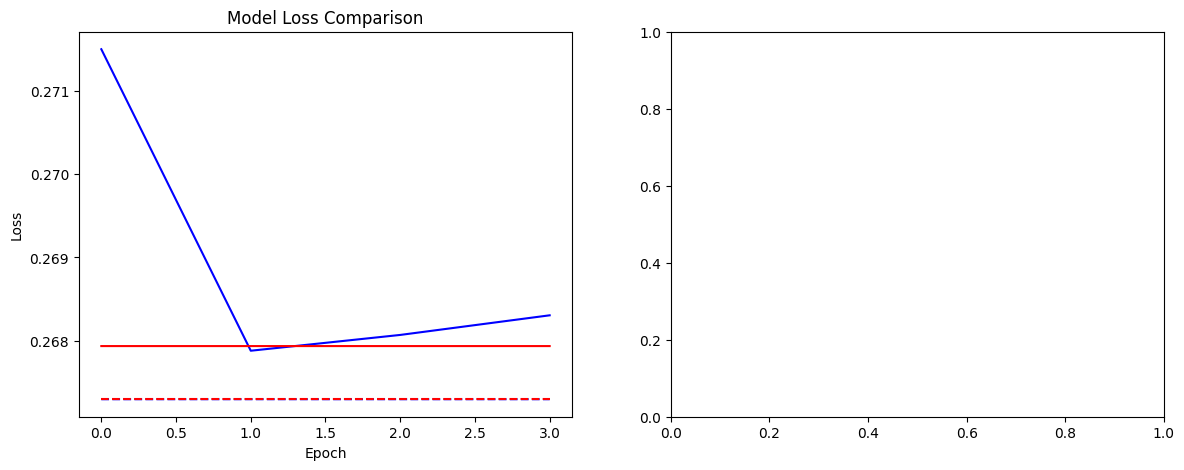

In [10]:
# Step 7 — Compare Both Models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
baseline_preds = baseline_model.predict(X_test).flatten()
deepfm_preds = deepfm_model.predict(X_test).flatten()

# Calculate metrics
baseline_mse = mean_squared_error(y_test, baseline_preds)
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_r2  = r2_score(y_test, baseline_preds)

deepfm_mse = mean_squared_error(y_test, deepfm_preds)
deepfm_mae = mean_absolute_error(y_test, deepfm_preds)
deepfm_r2  = r2_score(y_test, deepfm_preds)

print("=" * 45)
print(f"{'Metric':<15} {'Baseline':>10} {'DeepFM':>10}")
print("=" * 45)
print(f"{'MSE':<15} {baseline_mse:>10.4f} {deepfm_mse:>10.4f}")
print(f"{'MAE':<15} {baseline_mae:>10.4f} {deepfm_mae:>10.4f}")
print(f"{'R2 Score':<15} {baseline_r2:>10.4f} {deepfm_r2:>10.4f}")
print("=" * 45)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(baseline_history.history['loss'], label='Baseline Train', color='blue')
axes[0].plot(baseline_history.history['val_loss'], label='Baseline Val', color='blue', linestyle='--')
axes[0].plot(deepfm_history.history['loss'], label='DeepFM Train', color='red')
axes[0].plot(deepfm_history.history['val_loss'], label='DeepFM Val', color='red', linestyle='--')
axes[0].set_title('Model Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

Target variable stats:
count    36673.000000
mean         0.552676
std          0.260212
min          0.100000
25%          0.330000
50%          0.550000
75%          0.780000
max          1.000000
Name: Probability_of_Recommendation, dtype: float64

Correlation with target:
Probability_of_Recommendation    1.000000
interaction_score                0.002565
income                           0.001730
Age                             -0.008595
Product_Rating                  -0.020740
Price                           -0.023779
Name: Probability_of_Recommendation, dtype: float64


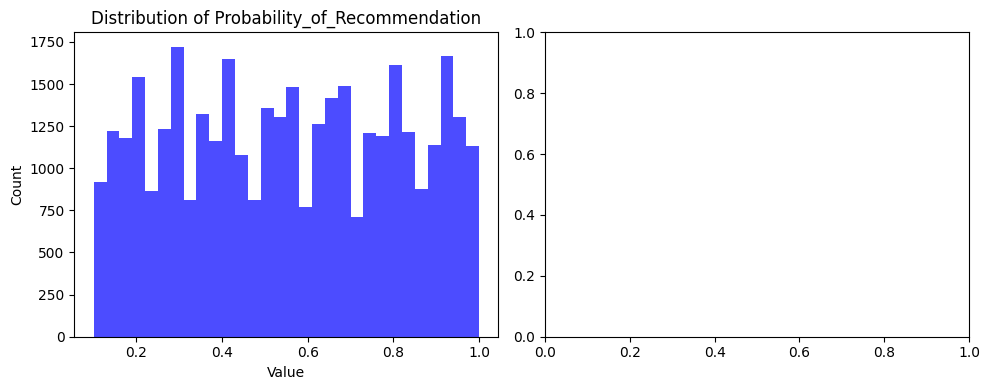

In [11]:
# Investigate the target variable
import matplotlib.pyplot as plt

print("Target variable stats:")
print(df['Probability_of_Recommendation'].describe())

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['Probability_of_Recommendation'], bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Probability_of_Recommendation')
plt.xlabel('Value')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
# Check correlation with a few key features
corr = df[['Probability_of_Recommendation', 'Product_Rating',
           'interaction_score', 'Price', 'Age', 'income']].corr()
print("\nCorrelation with target:")
print(corr['Probability_of_Recommendation'].sort_values(ascending=False))

plt.tight_layout()
plt.show()

In [12]:
# Create a real target variable based on actual user behavior
# Reload original data fresh
df2 = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')

# Create binary target: 1 if purchased, 0 otherwise
df2['target'] = (df2['event_type'] == 'purchase').astype(int)

print("Target distribution:")
print(df2['target'].value_counts())
print(f"\nPurchase rate: {df2['target'].mean():.2%}")

# Check correlation now
df2_encoded = df2.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['event_type', 'Gender', 'Category', 'price_segment', 'engagement_level']:
    df2_encoded[col] = le.fit_transform(df2_encoded[col].astype(str))

corr = df2_encoded[['target', 'Product_Rating', 'interaction_score',
                     'Price', 'Age', 'income', 'engagement_level']].corr()
print("\nCorrelation with new target:")
print(corr['target'].sort_values(ascending=False))

Target distribution:
target
0    34041
1     2632
Name: count, dtype: int64

Purchase rate: 7.18%

Correlation with new target:
target               1.000000
interaction_score    0.709235
Age                  0.007380
Price                0.005973
income               0.002812
Product_Rating      -0.006021
engagement_level    -0.545558
Name: target, dtype: float64


In [13]:
# Retrain with proper target variable
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Categorical features
categorical_cols = [
    'Customer_ID', 'Product_ID', 'Category', 'Subcategory',
    'event_type', 'Gender', 'Location',
    'Customer_Segment', 'price_segment', 'engagement_level',
    'Season_x'
]

# Numerical features
numerical_cols = [
    'Age', 'Price', 'income', 'Interaction_Value',
    'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
    'Product_Rating', 'browse_count', 'purchase_count',
    'interaction_score', 'already_purchased'
]

# Encode categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df2[col] = le.fit_transform(df2[col].astype(str))
    label_encoders[col] = le

# Scale numerical columns
scaler = MinMaxScaler()
df2[numerical_cols] = scaler.fit_transform(df2[numerical_cols])

# Prepare X and y with NEW target
feature_cols = categorical_cols + numerical_cols
X = df2[feature_cols].values
y = df2['target'].values

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")
print(f"Purchase rate in train: {y_train.mean():.2%}")
print(f"Purchase rate in test : {y_test.mean():.2%}")

Training samples : 29338
Testing samples  : 7335
Purchase rate in train: 7.18%
Purchase rate in test : 7.17%


In [14]:
# Retrain Baseline Model with new target
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Handle class imbalance (only 7% purchases)
# We give more weight to purchase class
class_weight = {0: 1, 1: 10}

# Build baseline model
def build_baseline_model(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

baseline_model2 = build_baseline_model(X_train.shape[1])

print("Training baseline model...")
baseline_history2 = baseline_model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)
print("\nBaseline training complete!")

Training baseline model...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.6762 - loss: 218.7131 - val_accuracy: 0.4229 - val_loss: 4.7359
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5936 - loss: 29.6779 - val_accuracy: 0.4896 - val_loss: 2.3671
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5988 - loss: 10.4282 - val_accuracy: 0.0717 - val_loss: 1.4074
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5742 - loss: 5.2309 - val_accuracy: 0.8545 - val_loss: 0.4435
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5521 - loss: 2.8063 - val_accuracy: 0.6363 - val_loss: 0.6634
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4848 - loss: 2.0045 - val_accuracy: 0.7568 - val_loss: 0.4967
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5410 - loss: 1.6630 - val_accuracy: 0.7123 - val_loss: 0.5753

Baseline training complete!


In [15]:
# Build and Train DeepFM with new target
import tensorflow.keras.backend as K
from tensorflow.keras.layers import Concatenate, Lambda

def build_deepfm_model(num_features):
    inputs = Input(shape=(num_features,))

    # FM Part - First order
    first_order = Dense(1, use_bias=True)(inputs)

    # FM Part - Second order interactions
    square_of_sum = Lambda(lambda x: K.square(
        K.sum(K.expand_dims(x, axis=-1), axis=1)))(inputs)

    sum_of_square = Lambda(lambda x: K.sum(
        K.square(K.expand_dims(x, axis=-1)), axis=1))(inputs)

    fm_second_order = Lambda(
        lambda x: 0.5 * K.sum(x[0] - x[1], axis=1, keepdims=True)
    )([square_of_sum, sum_of_square])

    # Deep Part
    deep = Dense(400, activation='relu')(inputs)
    deep = Dropout(0.3)(deep)
    deep = Dense(400, activation='relu')(deep)
    deep = Dropout(0.3)(deep)
    deep = Dense(400, activation='relu')(deep)
    deep = Dropout(0.3)(deep)

    # Combine FM + Deep
    combined = Concatenate()([first_order, fm_second_order, deep])
    output = Dense(1, activation='sigmoid')(combined)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

deepfm_model2 = build_deepfm_model(X_train.shape[1])

print("Training DeepFM model...")
deepfm_history2 = deepfm_model2.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)
print("\nDeepFM training complete!")

Training DeepFM model...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.5503 - loss: 8451.1162 - val_accuracy: 0.2584 - val_loss: 136.9492
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5330 - loss: 518.2835 - val_accuracy: 0.8481 - val_loss: 7.6686
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5005 - loss: 708.8689 - val_accuracy: 0.0766 - val_loss: 900.5582
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5492 - loss: 1104.4760 - val_accuracy: 0.9283 - val_loss: 133.6089
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5840 - loss: 1194.4711 - val_accuracy: 0.0717 - val_loss: 1417.4904

DeepFM training complete!


In [16]:
# Fixed DeepFM Model
def build_deepfm_fixed(num_features):
    inputs = Input(shape=(num_features,))

    # FM Part - First order (linear)
    first_order = Dense(1, use_bias=True)(inputs)

    # FM Part - Second order (simplified and stable)
    fm_dense = Dense(16, activation='relu')(inputs)
    fm_second = Dense(1)(fm_dense)

    # Deep Part
    deep = Dense(256, activation='relu')(inputs)
    deep = Dropout(0.3)(deep)
    deep = Dense(128, activation='relu')(deep)
    deep = Dropout(0.3)(deep)
    deep = Dense(64, activation='relu')(deep)
    deep = Dropout(0.3)(deep)

    # Combine FM + Deep
    combined = Concatenate()([first_order, fm_second, deep])
    combined = Dense(32, activation='relu')(combined)
    output = Dense(1, activation='sigmoid')(combined)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

deepfm_model3 = build_deepfm_fixed(X_train.shape[1])
deepfm_model3.summary()

print("\nTraining Fixed DeepFM model...")
deepfm_history3 = deepfm_model3.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)
print("\nDeepFM training complete!")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 256)       │      6,400 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 256)       │          0 │ dense_21[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     32,896 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 16)        │        400 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1)         │         25 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 1)         │         17 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ dense_23[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 66)        │          0 │ dense_18[0][0],   │
│ (Concatenate)       │                   │            │ dense_20[0][0],   │
│                     │                   │            │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │      2,144 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1)         │         33 │ dense_24[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,171 (195.98 KB)

 Trainable params: 50,171 (195.98 KB)

 Non-trainable params: 0 (0.00 B)


Training Fixed DeepFM model...
Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.5046 - loss: 169.3200 - val_accuracy: 0.2311 - val_loss: 8.2660
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5839 - loss: 19.5713 - val_accuracy: 0.4618 - val_loss: 1.2423
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5561 - loss: 7.4108 - val_accuracy: 0.1059 - val_loss: 1.4040
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5388 - loss: 3.2241 - val_accuracy: 0.6130 - val_loss: 0.7058
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5671 - loss: 1.9824 - val_accuracy: 0.0746 - val_loss: 1.0914
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5922 - loss: 1.5252 - val_accuracy: 0.4450 - val_loss: 0.7142
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6044 - loss: 1.4325 - val_accuracy: 0.9283 - val_loss: 0.3417
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6071 - loss: 1.46